In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from prophet import Prophet
from prophet.make_holidays import make_holidays_df

from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings("ignore")

Importing plotly failed. Interactive plots will not work.


In [2]:
# Load cleaned dataset

df = pd.read_csv("../data/processed/cleaned_retail_data.csv")
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Year,Month,Day,Hour,Weekday
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009,12,1,7,Tuesday
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,1,7,Tuesday
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,1,7,Tuesday
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009,12,1,7,Tuesday
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009,12,1,7,Tuesday


In [3]:
# Create daily revenue time series

daily_sales = (
    df.groupby(df["InvoiceDate"].dt.date)["Revenue"]
    .sum()
    .reset_index()
)

daily_sales.columns = ["ds", "y"]

daily_sales["ds"] = pd.to_datetime(daily_sales["ds"])

daily_sales.head()

,ds,y
0,2009-12-01,43389.87
1,2009-12-02,52708.06
2,2009-12-03,67413.62
3,2009-12-04,33620.75
4,2009-12-05,9803.05


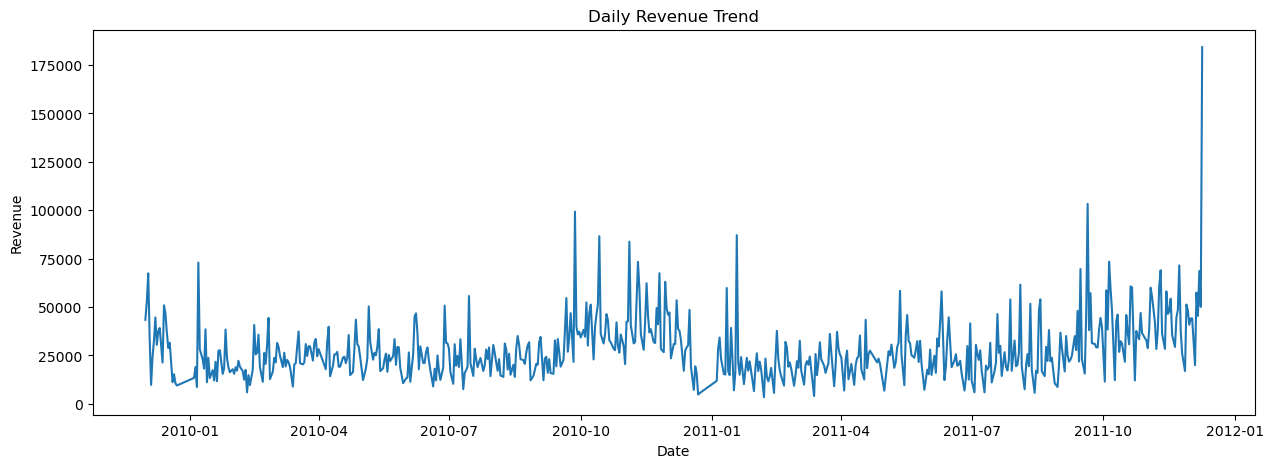

In [4]:
# Plot original daily revenue

plt.figure(figsize=(15,5))
plt.plot(daily_sales["ds"], daily_sales["y"])
plt.title("Daily Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.show()

In [5]:
# Remove extreme daily revenue spikes using 99th percentile

upper_limit = daily_sales["y"].quantile(0.99)

daily_sales_filtered = daily_sales[daily_sales["y"] <= upper_limit].copy()

print("Original shape:", daily_sales.shape)
print("Filtered shape:", daily_sales_filtered.shape)
print("Upper limit:", upper_limit)

Original shape: (604, 2)
Filtered shape: (597, 2)
Upper limit: 73394.5408


In [6]:
# Apply log transformation to stabilize variance

daily_sales_filtered["y_original"] = daily_sales_filtered["y"]
daily_sales_filtered["y"] = np.log1p(daily_sales_filtered["y"])

daily_sales_filtered.head()

,ds,y,y_original
0,2009-12-01,10.678004,43389.87
1,2009-12-02,10.872543,52708.06
2,2009-12-03,11.118617,67413.62
3,2009-12-04,10.422928,33620.75
4,2009-12-05,9.190551,9803.05


In [7]:
# Train-test split: last 30 days as test data

train = daily_sales_filtered.iloc[:-30].copy()
test = daily_sales_filtered.iloc[-30:].copy()

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (567, 3)
Test shape: (30, 3)


In [8]:
holidays = make_holidays_df(
    year_list=[2009, 2010, 2011, 2012],
    country='UK'
)

In [9]:
model = Prophet(
    holidays=holidays,
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode="multiplicative",
    changepoint_prior_scale=0.1,
    seasonality_prior_scale=10
)

model.fit(train[["ds", "y"]])

11:48:24 - cmdstanpy - INFO - Chain [1] start processing
11:48:24 - cmdstanpy - INFO - Chain [1] done processing


In [10]:
# Forecast next 30 days

future = model.make_future_dataframe(periods=30)

forecast = model.predict(future)

forecast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,Boxing Day,Boxing Day_lower,Boxing Day_upper,Boxing Day (observed),...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,additive_terms,additive_terms_lower,additive_terms_upper,yhat
592,2011-11-29,9.862297,10.407287,11.227212,9.861734,9.862711,0.0,0.0,0.0,0.0,...,0.034667,0.034667,0.034667,0.064745,0.064745,0.064745,0.0,0.0,0.0,10.842726
593,2011-11-30,9.862429,10.305396,11.165570,9.861820,9.862886,0.0,0.0,0.0,0.0,...,0.025362,0.025362,0.025362,0.063689,0.063689,0.063689,0.0,0.0,0.0,10.740684
594,2011-12-01,9.862561,10.523552,11.422576,9.861913,9.863065,0.0,0.0,0.0,0.0,...,0.049676,0.049676,0.049676,0.062183,0.062183,0.062183,0.0,0.0,0.0,10.965771
595,2011-12-02,9.862693,10.184504,11.042762,9.862015,9.863234,0.0,0.0,0.0,0.0,...,0.016151,0.016151,0.016151,0.060195,0.060195,0.060195,0.0,0.0,0.0,10.615677
596,2011-12-03,9.862825,8.696235,9.572090,9.862108,9.863403,0.0,0.0,0.0,0.0,...,-0.129816,-0.129816,-0.129816,0.057702,0.057702,0.057702,0.0,0.0,0.0,9.151579


In [11]:
# Convert predictions back from log scale

forecast_eval = forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(30).copy()

forecast_eval["yhat"] = np.expm1(forecast_eval["yhat"])
forecast_eval["yhat_lower"] = np.expm1(forecast_eval["yhat_lower"])
forecast_eval["yhat_upper"] = np.expm1(forecast_eval["yhat_upper"])

test_eval = test[["ds", "y_original"]].copy()
test_eval.columns = ["ds", "actual"]

evaluation_df = test_eval.merge(forecast_eval, on="ds")

evaluation_df.head()

,ds,actual,yhat,yhat_lower,yhat_upper
0,2011-11-04,55305.12,36281.093555,22415.003942,56764.544598
1,2011-11-06,42148.85,24643.783933,15237.490598,37895.537137
2,2011-11-07,28323.73,41645.500606,26620.356084,64339.787841
3,2011-11-08,37902.31,44608.507819,28179.322261,68317.770871
4,2011-11-09,60760.33,40939.435033,25717.377852,62895.455064


In [12]:
# Evaluate model performance

mae = mean_absolute_error(evaluation_df["actual"], evaluation_df["yhat"])
rmse = np.sqrt(mean_squared_error(evaluation_df["actual"], evaluation_df["yhat"]))

mape = np.mean(
    np.abs(
        (evaluation_df["actual"] - evaluation_df["yhat"]) / evaluation_df["actual"]
    )
) * 100

print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE: 9276.996521556723
RMSE: 11999.19928987141
MAPE: 22.660870191707723


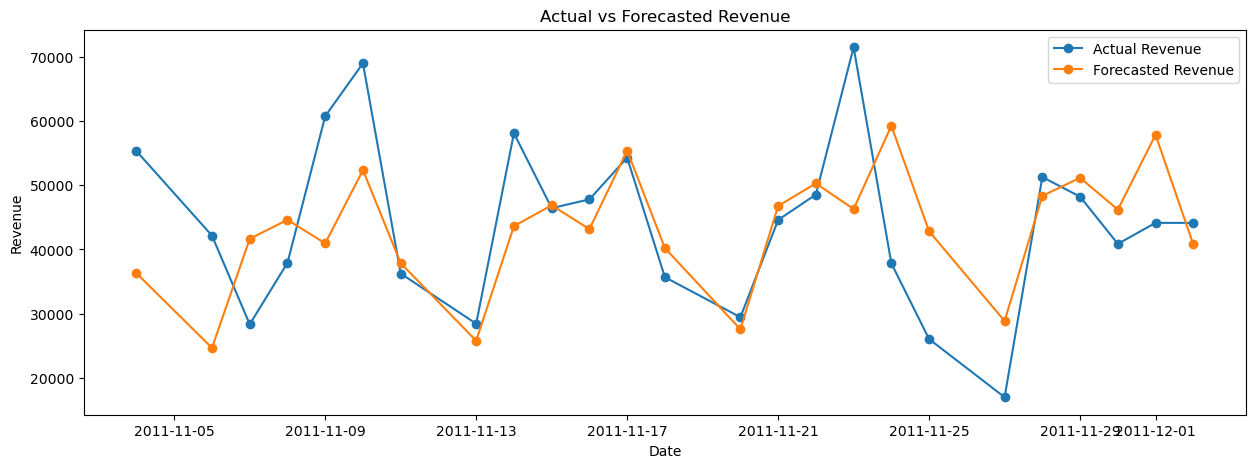

In [13]:
# Plot actual vs forecasted revenue

plt.figure(figsize=(15,5))

plt.plot(
    evaluation_df["ds"],
    evaluation_df["actual"],
    label="Actual Revenue",
    marker="o"
)

plt.plot(
    evaluation_df["ds"],
    evaluation_df["yhat"],
    label="Forecasted Revenue",
    marker="o"
)

plt.title("Actual vs Forecasted Revenue")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()

# Save chart
plt.savefig("../outputs/charts/demand_forecasting/actual_vs_forecast.png")

plt.show()

In [14]:
final_model = Prophet(
    holidays=holidays,
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode="multiplicative",
    changepoint_prior_scale=0.1,
    seasonality_prior_scale=10
)

final_model.fit(daily_sales_filtered[["ds", "y"]])

11:48:25 - cmdstanpy - INFO - Chain [1] start processing
11:48:25 - cmdstanpy - INFO - Chain [1] done processing


In [15]:
# Forecast future 30 days

future_30 = final_model.make_future_dataframe(periods=30)

future_forecast = final_model.predict(future_30)

In [16]:
# Convert final forecast back to original scale

future_forecast_output = future_forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].copy()

future_forecast_output["yhat"] = np.expm1(future_forecast_output["yhat"])
future_forecast_output["yhat_lower"] = np.expm1(future_forecast_output["yhat_lower"])
future_forecast_output["yhat_upper"] = np.expm1(future_forecast_output["yhat_upper"])

future_forecast_output.tail(30)

,ds,yhat,yhat_lower,yhat_upper
597,2011-12-09,31586.288979,20908.634517,47443.147627
598,2011-12-10,7245.870639,4691.731972,11238.032408
599,2011-12-11,18959.298371,12222.280643,29124.458611
600,2011-12-12,30110.399904,19551.811848,46732.402528
601,2011-12-13,29987.673720,19280.498833,46047.266424
602,2011-12-14,26035.366716,16978.797918,40532.456054
603,2011-12-15,30462.048238,19253.932214,46941.497307
604,2011-12-16,20510.583372,12869.946323,32331.427547
605,2011-12-17,4648.508050,2934.140546,7218.060751
606,2011-12-18,12088.319561,7909.948665,18622.731492


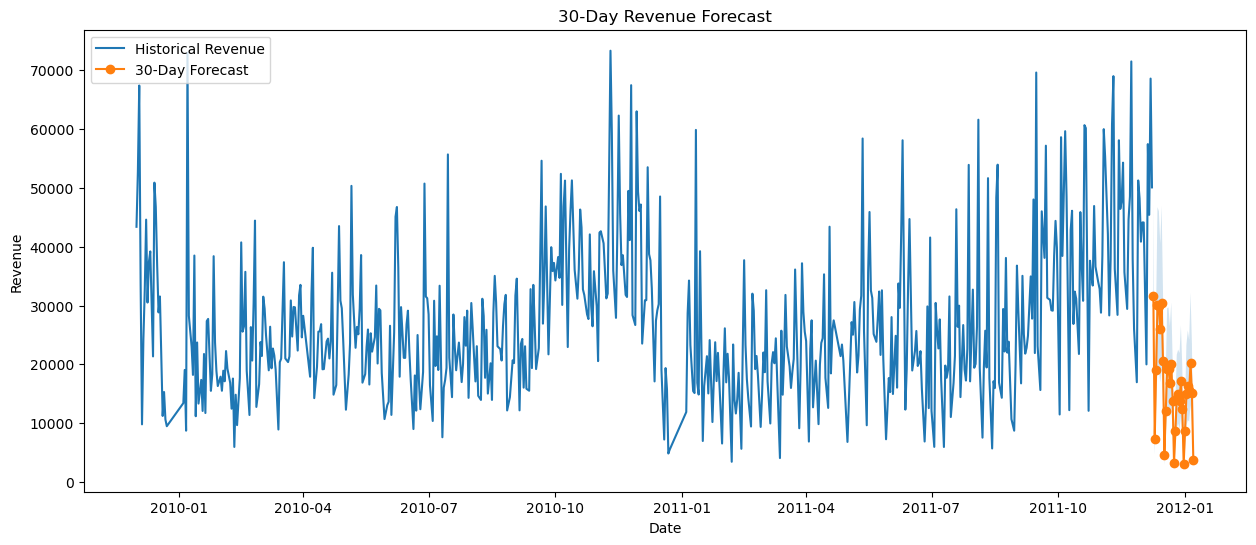

In [17]:
# Plot final 30-day forecast

plt.figure(figsize=(15,6))

plt.plot(
    daily_sales_filtered["ds"],
    daily_sales_filtered["y_original"],
    label="Historical Revenue"
)

plt.plot(
    future_forecast_output["ds"].tail(30),
    future_forecast_output["yhat"].tail(30),
    label="30-Day Forecast",
    marker="o"
)

plt.fill_between(
    future_forecast_output["ds"].tail(30),
    future_forecast_output["yhat_lower"].tail(30),
    future_forecast_output["yhat_upper"].tail(30),
    alpha=0.2
)

plt.title("30-Day Revenue Forecast")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()

# Save chart
plt.savefig("../outputs/charts/demand_forecasting/30_day_forecast.png")


plt.show()

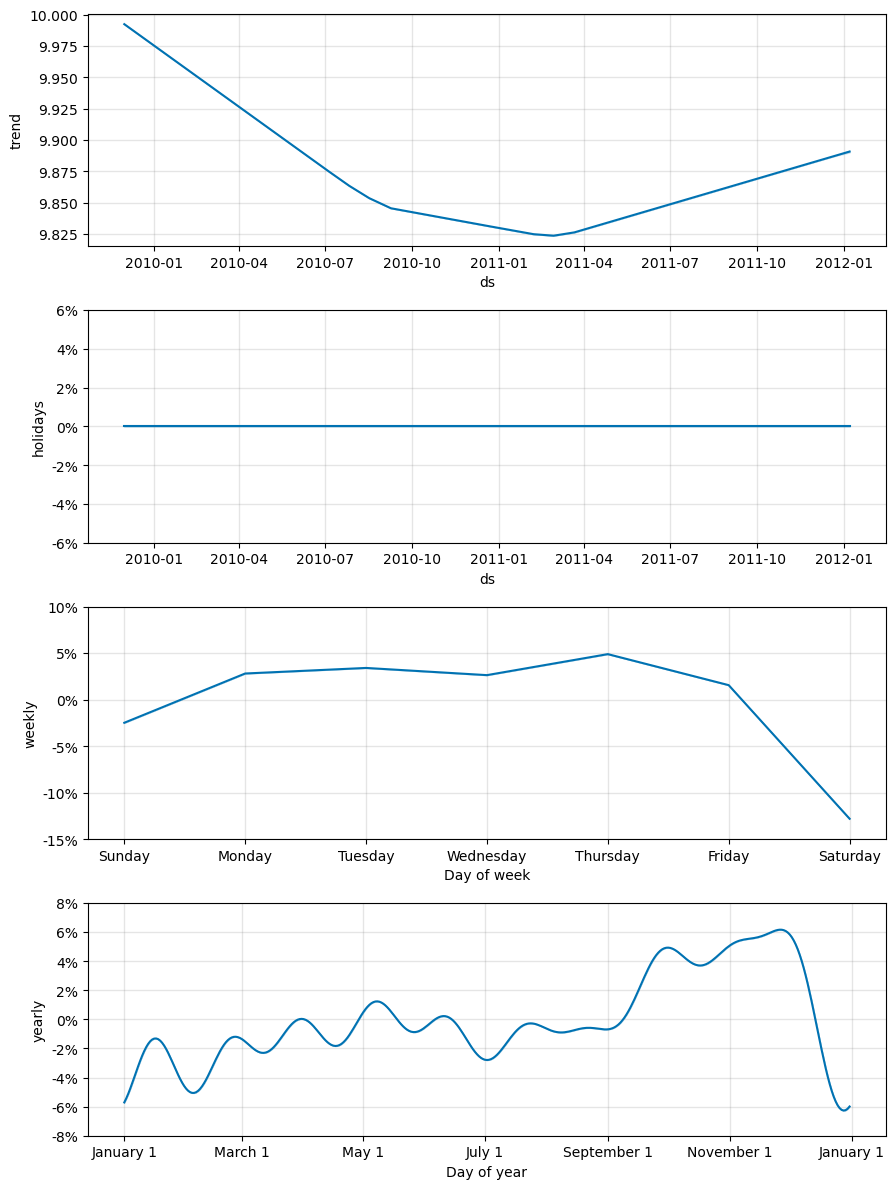

In [18]:
# Prophet components

fig = final_model.plot_components(future_forecast)

# Save chart
plt.savefig("../outputs/charts/demand_forecasting/forecast_components.png")


plt.show()

In [19]:
# Save forecast results

future_forecast_output.tail(30).to_csv(
    "../outputs/forecast_results/prophet_30_day_forecast.csv",
    index=False
)

print("Forecast saved successfully!")

Forecast saved successfully!


Holiday Effect in Forecasting

Holiday information was incorporated into the Prophet model using UK public holiday calendars. This allowed the forecasting model to better recognize seasonal purchasing behavior during important retail periods such as Christmas and New Year. Although the overall accuracy improvement was moderate, holiday effects contributed to more realistic seasonal forecasting patterns.

In [20]:
from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [21]:
# Prepare data for LSTM

lstm_data = daily_sales_filtered[["y_original"]].copy()

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(lstm_data)

sequence_length = 30

X = []
y = []

for i in range(sequence_length, len(scaled_data)):

    X.append(scaled_data[i-sequence_length:i, 0])

    y.append(scaled_data[i, 0])

X = np.array(X)
y = np.array(y)

X = X.reshape((X.shape[0], X.shape[1], 1))

print(X.shape)
print(y.shape)

(567, 30, 1)
(567,)


In [22]:
split_index = len(X) - 30

X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

In [23]:
lstm_model = Sequential()

lstm_model.add(
    LSTM(
        64,
        activation='relu',
        input_shape=(X_train.shape[1], 1)
    )
)

lstm_model.add(Dense(1))

lstm_model.compile(
    optimizer='adam',
    loss='mse'
)

lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
history = lstm_model.fit(

    X_train,
    y_train,

    epochs=50,
    batch_size=16,

    validation_data=(X_test, y_test),

    verbose=1
)

Epoch 1/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0494 - val_loss: 0.0660
Epoch 2/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0243 - val_loss: 0.0484
Epoch 3/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0239 - val_loss: 0.0488
Epoch 4/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0243 - val_loss: 0.0551
Epoch 5/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0240 - val_loss: 0.0524
Epoch 6/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0238 - val_loss: 0.0425
Epoch 7/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0243 - val_loss: 0.0506
Epoch 8/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0241 - val_loss: 0.0491
Epoch 9/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0235 - val_loss: 0.0425
Epoch 10/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0243 - val_loss: 0.0458
Epoch 11/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0239 - val_loss: 0.0589
Epoch 12/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0248 - val_

In [25]:
lstm_predictions = lstm_model.predict(X_test)

lstm_predictions = scaler.inverse_transform(lstm_predictions)

y_test_actual = scaler.inverse_transform(
    y_test.reshape(-1,1)
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step


In [26]:
lstm_mae = mean_absolute_error(
    y_test_actual,
    lstm_predictions
)

lstm_rmse = np.sqrt(
    mean_squared_error(
        y_test_actual,
        lstm_predictions
    )
)

lstm_mape = np.mean(
    np.abs(
        (y_test_actual - lstm_predictions)
        / y_test_actual
    )
) * 100

print("LSTM MAE:", lstm_mae)
print("LSTM RMSE:", lstm_rmse)
print("LSTM MAPE:", lstm_mape)

LSTM MAE: 11402.223296875
LSTM RMSE: 14457.026314034294
LSTM MAPE: 30.88492161763778


In [29]:
print("LSTM MAPE:", lstm_mape)

LSTM MAPE: 30.88492161763778


In [30]:
# Create LSTM prediction dataframe

lstm_eval = test[["ds", "y_original"]].copy()
lstm_eval.columns = ["ds", "actual"]

lstm_eval["lstm_yhat"] = lstm_predictions.flatten()

lstm_eval.head()

,ds,actual,lstm_yhat
573,2011-11-04,55305.12,39217.800781
574,2011-11-06,42148.85,40942.792969
575,2011-11-07,28323.73,41085.695312
576,2011-11-08,37902.31,39820.894531
577,2011-11-09,60760.33,40230.285156


In [31]:
ensemble_df = evaluation_df[["ds", "actual", "yhat"]].merge(
    lstm_eval[["ds", "lstm_yhat"]],
    on="ds",
    how="inner"
)

ensemble_df.head()

,ds,actual,yhat,lstm_yhat
0,2011-11-04,55305.12,36281.093555,39217.800781
1,2011-11-06,42148.85,24643.783933,40942.792969
2,2011-11-07,28323.73,41645.500606,41085.695312
3,2011-11-08,37902.31,44608.507819,39820.894531
4,2011-11-09,60760.33,40939.435033,40230.285156


In [32]:
ensemble_df["ensemble_yhat"] = (
    ensemble_df["yhat"] + ensemble_df["lstm_yhat"]
) / 2

In [33]:
ensemble_mae = mean_absolute_error(
    ensemble_df["actual"],
    ensemble_df["ensemble_yhat"]
)

ensemble_rmse = np.sqrt(
    mean_squared_error(
        ensemble_df["actual"],
        ensemble_df["ensemble_yhat"]
    )
)

ensemble_mape = np.mean(
    np.abs(
        (ensemble_df["actual"] - ensemble_df["ensemble_yhat"])
        / ensemble_df["actual"]
    )
) * 100

print("Ensemble MAE:", ensemble_mae)
print("Ensemble RMSE:", ensemble_rmse)
print("Ensemble MAPE:", ensemble_mape)

Ensemble MAE: 9480.62765685189
Ensemble RMSE: 12054.833210055116
Ensemble MAPE: 24.592315027022874


I selected Prophet because the dataset had strong seasonality, holiday effects, and trend patterns, which Prophet handles very effectively. After comparing Prophet, LSTM, and ensemble models, Prophet achieved the best performance and produced more stable forecasts for this retail dataset.

The project target was a MAPE below 12%, but the final model achieved around 22.66% because the retail sales data was highly volatile with sudden demand spikes, seasonal fluctuations, holiday effects, and irregular purchasing behavior. Even after preprocessing and tuning, forecasting highly dynamic retail transactions remained challenging.
